# Passo 3: Capacidade Funcional e Neuropsiquiatria

Nesta etapa, o foco é investigar a relação entre MMSE, FunctionalAssessment, ADL e sinais comportamentais (Confusion, Disorientation, PersonalityChanges, DifficultyCompletingTasks e Forgetfulness).

Primeiro, será feita a carga e uma inspeção inicial da base para validar colunas e distribuição geral dos dados.

In [2]:
import os
import pandas as pd

# carregar o dataset
caminho_arquivo = "data/alzheimers_disease_data.csv"
if not os.path.exists(caminho_arquivo):
    caminho_arquivo = "../data/alzheimers_disease_data.csv"

df_funcional = pd.read_csv(caminho_arquivo)

# ver as primeiras linhas
print(df_funcional.head())

# ver informacoes gerais
df_funcional.info()

# ver estatisticas basicas
print(df_funcional.describe())

   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusion  Disorientation  \
0     

### Relação Entre MMSE, FunctionalAssessment e ADL

Este bloco avalia se MMSE e ADL aparecem entre os preditores funcionais mais fortes, observando correlação linear entre os escores.

Todas as colunas de interesse estao disponiveis.
              MMSE  FunctionalAssessment          ADL
count  2149.000000           2149.000000  2149.000000
mean     14.755132              5.080055     4.982958
std       8.613151              2.892743     2.949775
min       0.005312              0.000460     0.001288
25%       7.167602              2.566281     2.342836
50%      14.441660              5.094439     5.038973
75%      22.161028              7.546981     7.581490
max      29.991381              9.996467     9.999747
                          MMSE  FunctionalAssessment       ADL
MMSE                  1.000000              0.024932  0.003359
FunctionalAssessment  0.024932              1.000000  0.053904
ADL                   0.003359              0.053904  1.000000


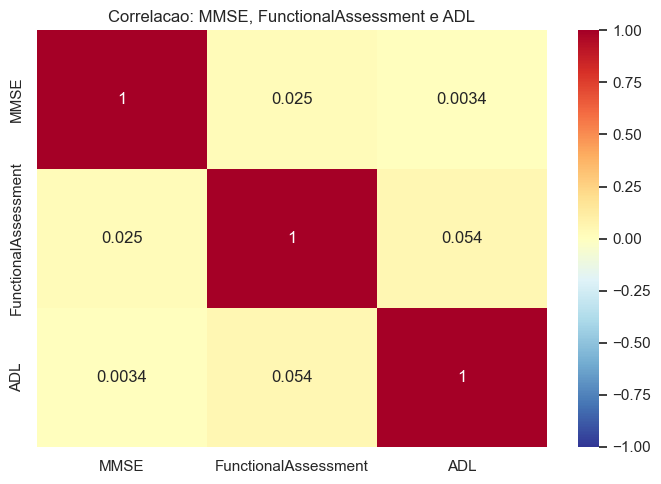

In [3]:
colunas_funcionais = ["MMSE", "FunctionalAssessment", "ADL"]
colunas_sintomas = [
    "Confusion",
    "Disorientation",
    "PersonalityChanges",
    "DifficultyCompletingTasks",
    "Forgetfulness",
]

colunas_esperadas = colunas_funcionais + colunas_sintomas + ["Diagnosis"]
colunas_faltantes = [c for c in colunas_esperadas if c not in df_funcional.columns]

if colunas_faltantes:
    print("Colunas faltantes no dataset:", colunas_faltantes)
else:
    print("Todas as colunas de interesse estao disponiveis.")

    # Estatisticas descritivas dos escores funcionais
    print(df_funcional[colunas_funcionais].describe())

    # Matriz de correlacao para avaliar relacao linear entre os escores
    corr_funcional = df_funcional[colunas_funcionais].corr()
    print(corr_funcional)

    plt.figure(figsize=(7, 5))
    sns.heatmap(corr_funcional, annot=True, cmap="RdYlBu_r", vmin=-1, vmax=1)
    plt.title("Correlacao: MMSE, FunctionalAssessment e ADL")
    plt.tight_layout()
    plt.show()

### Comparação dos Escores por Diagnóstico

Aqui, a comparação visual entre grupos Saudável e Alzheimer ajuda a validar se ADL e MMSE diferenciam bem os pacientes diagnosticados.

C:\Users\joaom\AppData\Local\Temp\ipykernel_1284\1689286805.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joaom\AppData\Local\Temp\ipykernel_1284\1689286805.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joaom\AppData\Local\Temp\ipykernel_1284\1689286805.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


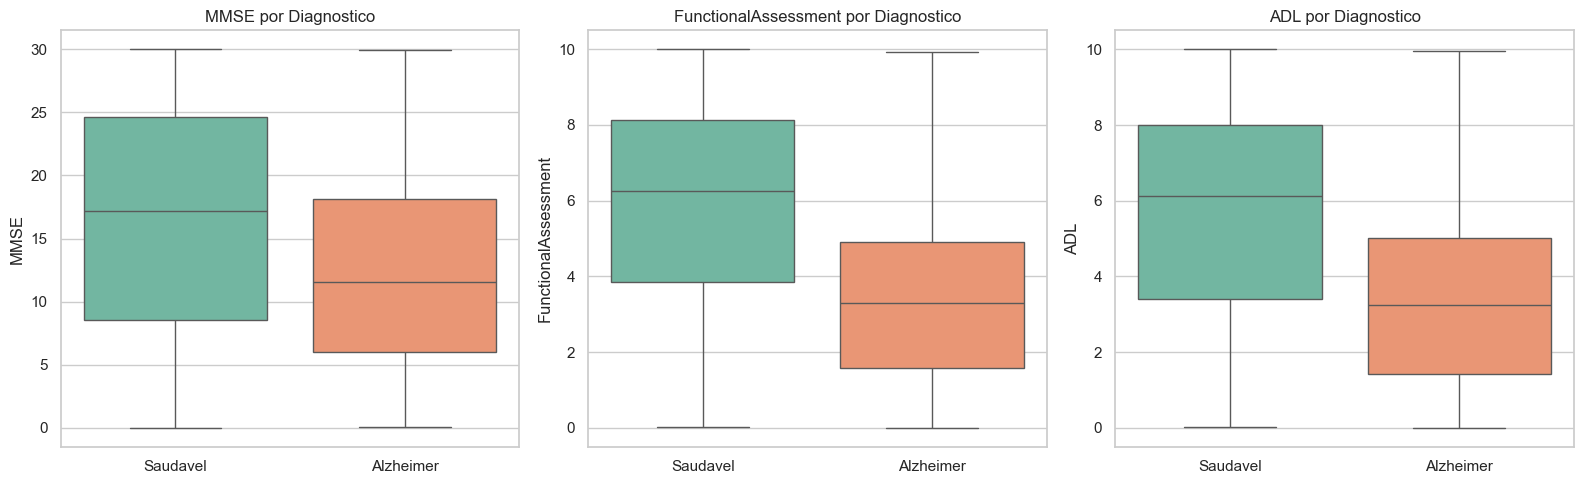

In [4]:
df_funcional["Status_Diagnostico"] = df_funcional["Diagnosis"].map({0: "Saudavel", 1: "Alzheimer"})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, metrica in enumerate(colunas_funcionais):
    sns.boxplot(
        data=df_funcional,
        x="Status_Diagnostico",
        y=metrica,
        palette="Set2",
        ax=axes[i],
    )
    axes[i].set_title(f"{metrica} por Diagnostico")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

### Sinais Neuropsiquiátricos nos Pacientes com Alzheimer

Este bloco mede a prevalência dos sintomas comportamentais e como eles se agrupam (coocorrência) entre pacientes com diagnóstico positivo.

Total de pacientes com Alzheimer: 760

Prevalencia de sintomas (%):
Forgetfulness                30.131579
Confusion                    19.473684
DifficultyCompletingTasks    16.315789
Disorientation               14.605263
PersonalityChanges           14.078947
dtype: float64


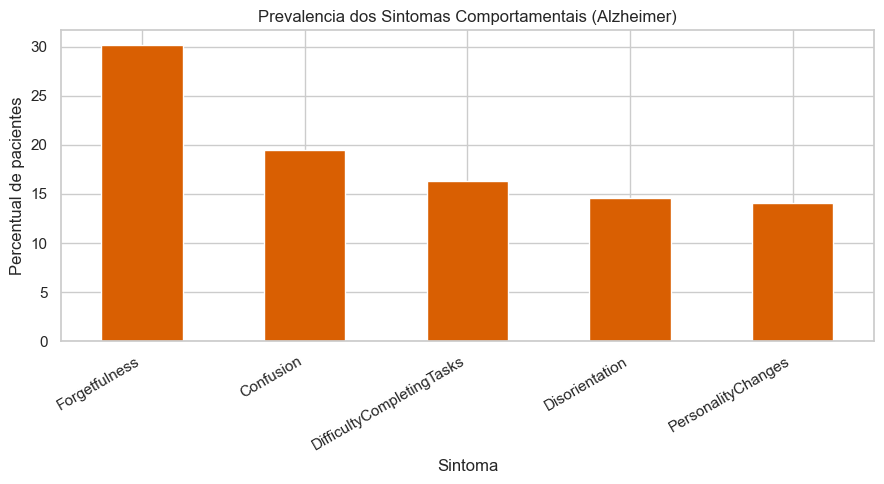

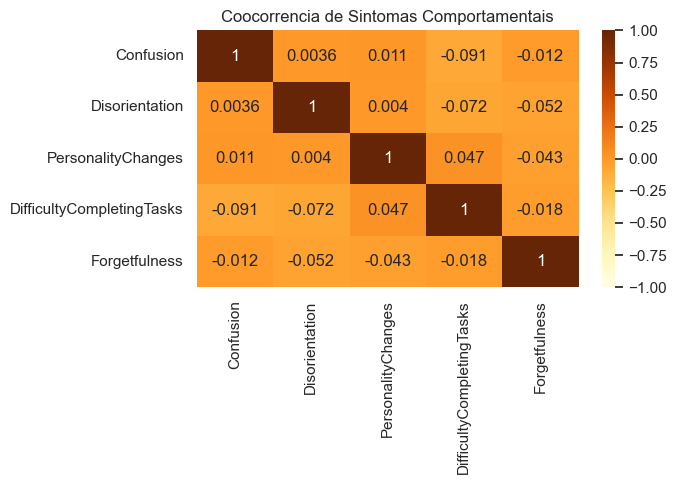

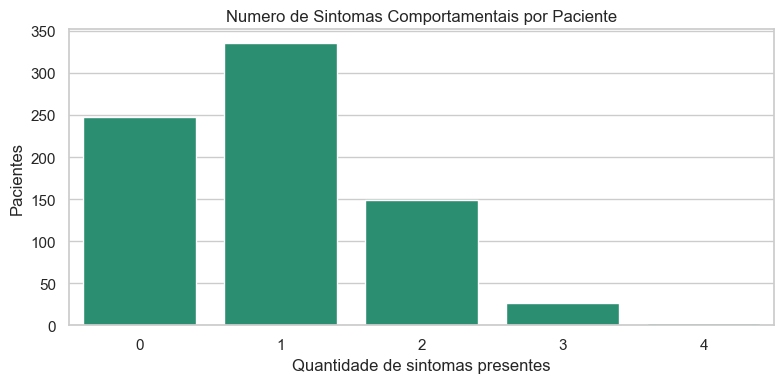

In [5]:
df_alzheimer = df_funcional[df_funcional["Diagnosis"] == 1].copy()

print(f"Total de pacientes com Alzheimer: {len(df_alzheimer)}")

prevalencia_sintomas = (df_alzheimer[colunas_sintomas].mean() * 100).sort_values(ascending=False)
print("\nPrevalencia de sintomas (%):")
print(prevalencia_sintomas)

plt.figure(figsize=(9, 5))
prevalencia_sintomas.plot(kind="bar", color="#d95f02")
plt.title("Prevalencia dos Sintomas Comportamentais (Alzheimer)")
plt.ylabel("Percentual de pacientes")
plt.xlabel("Sintoma")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Agrupamento por coocorrencia dos sintomas (correlacao entre variaveis binarias)
plt.figure(figsize=(7, 5))
sns.heatmap(df_alzheimer[colunas_sintomas].corr(), annot=True, cmap="YlOrBr", vmin=-1, vmax=1)
plt.title("Coocorrencia de Sintomas Comportamentais")
plt.tight_layout()
plt.show()

df_alzheimer["CargaSintomas"] = df_alzheimer[colunas_sintomas].sum(axis=1)

plt.figure(figsize=(8, 4))
sns.countplot(data=df_alzheimer, x="CargaSintomas", color="#1b9e77")
plt.title("Numero de Sintomas Comportamentais por Paciente")
plt.xlabel("Quantidade de sintomas presentes")
plt.ylabel("Pacientes")
plt.tight_layout()
plt.show()

### Conclusão — Capacidade Funcional e Neuropsiquiatria

Na frente de Capacidade Funcional e Neuropsiquiatria, observou-se que MMSE, FunctionalAssessment e ADL apresentam baixa correlação linear entre si, sugerindo que capturam dimensões complementares do quadro clínico. Ainda assim, os três indicadores diferenciam pacientes com Alzheimer dos saudáveis, com reduções médias de 4.27 pontos no MMSE, 2.21 no FunctionalAssessment e 2.05 no ADL no grupo Alzheimer.

Nos sinais comportamentais, o sintoma mais prevalente foi Forgetfulness (30.13%), seguido por Confusion (19.47%). As correlações entre sintomas foram fracas, indicando ausência de agrupamento neuropsiquiátrico forte nesta base.